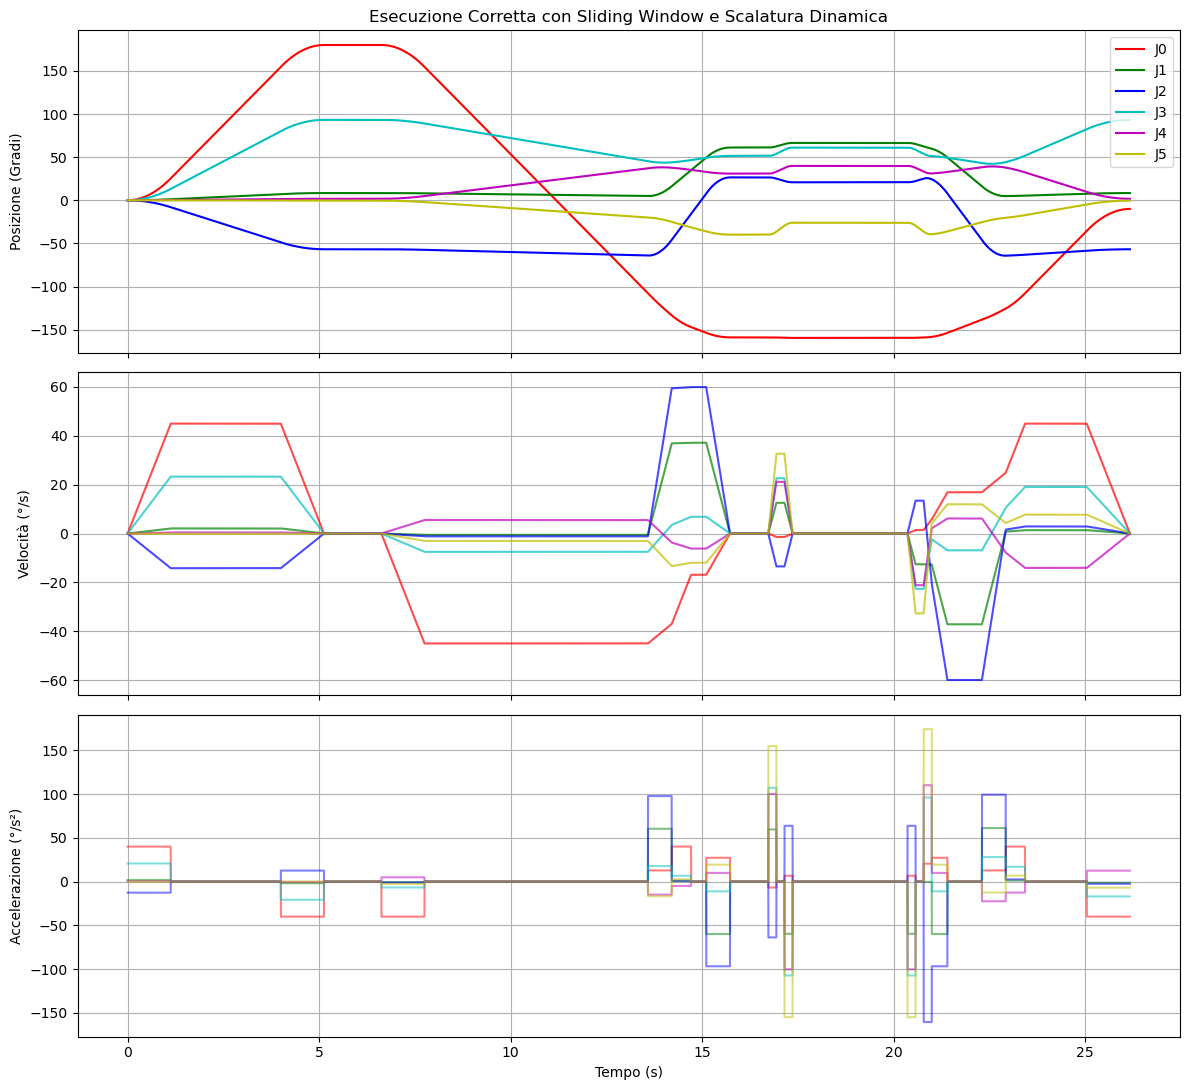

In [18]:
import numpy as np
import matplotlib.pyplot as plt

S_SCALE = 10000000.0  # Scala intera (0 - 10.000.000)
WINDOW_SIZE = 5       # Dimensione della finestra scorrevole (buffer RAM limitato)

# ==============================================================================
# 1. PARSER G-CODE
# ==============================================================================
def parse_gcode_to_blocks(gcode_text):
    blocks = []
    lines = gcode_text.strip().split('\n')
    last_q = np.zeros(6) 
    for line in lines:
        line = line.strip()
        if not line: continue
        parts = line.split()
        cmd = parts[0]
        
        if cmd == 'G1':
            q_target = np.copy(last_q)
            for p in parts[1:]:
                val = float(p[1:])
                if p.startswith('X'): q_target[0] = val
                elif p.startswith('Y'): q_target[1] = val
                elif p.startswith('Z'): q_target[2] = val
                elif p.startswith('A'): q_target[3] = val
                elif p.startswith('B'): q_target[4] = val
                elif p.startswith('C'): q_target[5] = val
            
            blocks.append({
                'type': 'MOTION',
                'q_target': np.copy(q_target),
                'delta_q': q_target - last_q
            })
            last_q = np.copy(q_target)
        elif cmd == 'G4':
            for p in parts[1:]:
                if p.startswith('P'): blocks.append({'type': 'DWELL', 'duration_ms': float(p[1:])})
        elif cmd == 'M280':
            blocks.append({'type': 'TOOL', 'raw': line})
    return blocks

# ==============================================================================
# 2. CINEMATICA (La tua matematica esatta)
# ==============================================================================
def compute_kinematic_pure_integration(delta_q, v_max_arr, a_max_arr, dt=0.001):
    mask = np.abs(delta_q) > 1e-6
    if not np.any(mask):
        return {'ticks_a': 0, 'ticks_v': 0, 'a_tick': 0.0, 'ticks_tot': 0}
        
    v_norm = np.min(v_max_arr[mask] / np.abs(delta_q[mask]))
    a_norm = np.min(a_max_arr[mask] / np.abs(delta_q[mask]))
    
    t_a = v_norm / a_norm
    s_a = 0.5 * a_norm * (t_a ** 2)
    
    if 2 * s_a > 1.0:  #evita il profilo triangolare 
        s_a_target = 0.25 #percentuale del tempo di accelllerazione e decellerazione 
        v_norm = np.sqrt(2.0 * a_norm * s_a_target)
        t_a = v_norm / a_norm
        s_v = 1.0 - (2.0 * s_a_target) 
        t_v = s_v / v_norm
    else: 
        t_v = (1.0 - 2 * s_a) / v_norm
        
    ticks_a = int(np.round(t_a / dt))
    ticks_v = int(np.round(t_v / dt))
    if ticks_a == 0: ticks_a = 1 
    
    a_tick = S_SCALE / (ticks_a * (ticks_a + 1 + ticks_v))
    
    return {
        'ticks_a': ticks_a,
        'ticks_v': ticks_v,
        'a_tick': a_tick,
        'ticks_tot': (2 * ticks_a) + ticks_v
    }

# ==============================================================================
# 3. CLASSE PROFILO ATTIVO (La tua logica esatta)
# ==============================================================================
class ActiveProfilePureIntegration:
    def __init__(self, block):
        self.block = block
        self.kin = block['kinematics']
        self.tick_counter = 0
        
        self.s = 0.0
        self.v = 0.0
        
        self.is_finished = False
        self.blend_triggered = False

    def tick(self):
        if self.tick_counter >= self.kin['ticks_tot']:
            self.s = S_SCALE
            self.v = 0.0
            self.is_finished = True
            return
            
        if self.tick_counter < self.kin['ticks_a']:
            a = self.kin['a_tick']
        elif self.tick_counter < (self.kin['ticks_a'] + self.kin['ticks_v']):
            a = 0.0
        else:
            a = -self.kin['a_tick']
            
        self.v += a
        self.s += self.v
        self.tick_counter += 1

# ==============================================================================
# 4. SIMULATORE DELLA SLIDING WINDOW CORRETTO
# ==============================================================================
def simulate_sliding_window(source_blocks, v_max_arr, a_max_arr, dt=0.001):
    time_log, q_log, v_log, a_log = [], [], [], []
    q_base = np.zeros(6)
    
    window = []
    source_idx = 0
    active_profiles = []
    current_time = 0.0
    
    # Sotto-funzione per tenere la finestra sempre piena (se ci sono blocchi disponibili)
    # e per aggiornare dinamicamente il flag 'blend_next' in base al contesto locale
    def refill_window():
        nonlocal source_idx
        # Aggiunge blocchi fino a riempire il buffer
        while len(window) < WINDOW_SIZE and source_idx < len(source_blocks):
            window.append(source_blocks[source_idx])
            source_idx += 1
            
        # Calcola cinematica e blending per il contenuto attuale
        for i in range(len(window)):
            b = window[i]
            if b['type'] == 'MOTION':
                if 'kinematics' not in b:
                    b['kinematics'] = compute_kinematic_pure_integration(b['delta_q'], v_max_arr, a_max_arr, dt)
                
                # Se c'è un blocco successivo ed è anch'esso di moto, abilita il blend
                if i + 1 < len(window) and window[i+1]['type'] == 'MOTION':
                    b['blend_next'] = True
                else:
                    b['blend_next'] = False

    # Ciclo Principale: continua finché c'è qualcosa da elaborare o in coda
    while active_profiles or source_idx < len(source_blocks) or window:
        refill_window()
        
        # Se non ci sono movimenti in corso, prendiamo in carico il primo blocco in finestra
        if not active_profiles and window:
            b = window[0] # Controlliamo il tipo prima di estrarlo definitivamente (Peek)
            
            if b['type'] == 'DWELL':
                window.pop(0) # Ora possiamo consumarlo
                steps = int(b['duration_ms'] / 1000.0 / dt)
                for _ in range(steps):
                    time_log.append(current_time)
                    q_log.append(np.copy(q_base))
                    v_log.append(np.zeros(6))
                    a_log.append(np.zeros(6))
                    current_time += dt
                continue
            elif b['type'] == 'TOOL':
                window.pop(0) 
                continue
            elif b['type'] == 'MOTION':
                window.pop(0) 
                active_profiles.append(ActiveProfilePureIntegration(b))
        
        # Elaborazione tic-by-tic dei profili attivi
        if active_profiles:
            current_q = np.copy(q_base)
            current_v = np.zeros(6)
            current_a = np.zeros(6)
            
            latest = active_profiles[-1]
            
            # Valutazione di un innesco per il blending con il blocco successivo
            if latest.block.get('blend_next', False) and not latest.blend_triggered:
                if latest.tick_counter >= (latest.kin['ticks_a'] + latest.kin['ticks_v']):
                    latest.blend_triggered = True
                    
                    refill_window() # Assicuriamoci che la finestra sia aggiornata
                    # Estrae il prossimo blocco SOLO se è un blocco di movimento
                    if window and window[0]['type'] == 'MOTION':
                        next_b = window.pop(0)
                        active_profiles.append(ActiveProfilePureIntegration(next_b))
            
            for p in active_profiles:
                if p.tick_counter < p.kin['ticks_a']:
                    inst_a = p.kin['a_tick']
                elif p.tick_counter < (p.kin['ticks_a'] + p.kin['ticks_v']):
                    inst_a = 0.0
                elif not p.is_finished:
                    inst_a = -p.kin['a_tick']
                else:
                    inst_a = 0.0

                p.tick() 
                
                frac = p.s / S_SCALE
                current_q += frac * p.block['delta_q']
                current_v += (p.v / S_SCALE) * p.block['delta_q'] / dt
                current_a += (inst_a / S_SCALE) * p.block['delta_q'] / (dt**2)
                
            # Rimozione dei profili che hanno completato il loro percorso
            for p in active_profiles[:]:
                if p.is_finished:
                    q_base += p.block['delta_q'] 
                    active_profiles.remove(p)
                    
            time_log.append(current_time)
            q_log.append(current_q)
            v_log.append(current_v)
            a_log.append(current_a)
            current_time += dt

    return np.array(time_log), np.array(q_log), np.array(v_log), np.array(a_log)

# ==============================================================================
# 5. ESECUZIONE E PLOT
# ==============================================================================
gcode_input = """
G1 X180 Y8.38 Z-56.78 A93.22 B1.73 C-0.42
G4 P1500.0
M280 P7 s180
G1 X-133.22 Y4.58 Z-64.74 A40.97 B40.29 C-21.60
G1 X-158.92 Y61.16 Z26.55 A51.45 B30.90 C-39.83
G4 P1000.0
G1 X-159.52 Y66.48 Z20.86 A61.02 B39.84 C-26.01
G4 P1000.0
M280 P7 s130
G4 P1000.0
M280 P7 s180
G4 P1000.0
G1 X-158.92 Y61.16 Z26.55 A51.45 B30.90 C-39.83
G1 X-133.22 Y4.58 Z-64.74 A40.97 B40.29 C-21.60
G1 X-10 Y8.38 Z-56.78 A93.22 B1.73 C-0.42
"""

V_MAX_ARRAY = np.array([45.0, 45.0, 60.0, 90.0, 120.0, 120.0])
A_MAX_ARRAY = np.array([40.0, 60.0, 100.0, 150.0, 200.0, 200.0])
DT = 0.001

raw_blocks = parse_gcode_to_blocks(gcode_input)
t_log, q_log, v_log, a_log = simulate_sliding_window(raw_blocks, V_MAX_ARRAY, A_MAX_ARRAY, dt=DT)

fig, axs = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
labels = ['J0', 'J1', 'J2', 'J3', 'J4', 'J5']
colors = ['r', 'g', 'b', 'c', 'm', 'y']

for j in range(6): axs[0].plot(t_log, q_log[:, j], color=colors[j], label=labels[j])
axs[0].set_ylabel('Posizione (Gradi)')
axs[0].set_title('Esecuzione Corretta con Sliding Window e Scalatura Dinamica')
axs[0].grid(True); axs[0].legend(loc='upper right')

for j in range(6): axs[1].plot(t_log, v_log[:, j], color=colors[j], alpha=0.7)
axs[1].set_ylabel('Velocità (°/s)')
axs[1].grid(True)

for j in range(6): axs[2].plot(t_log, a_log[:, j], color=colors[j], alpha=0.5)
axs[2].set_ylabel('Accelerazione (°/s²)')
axs[2].set_xlabel('Tempo (s)')
axs[2].grid(True)

plt.tight_layout()
plt.show()

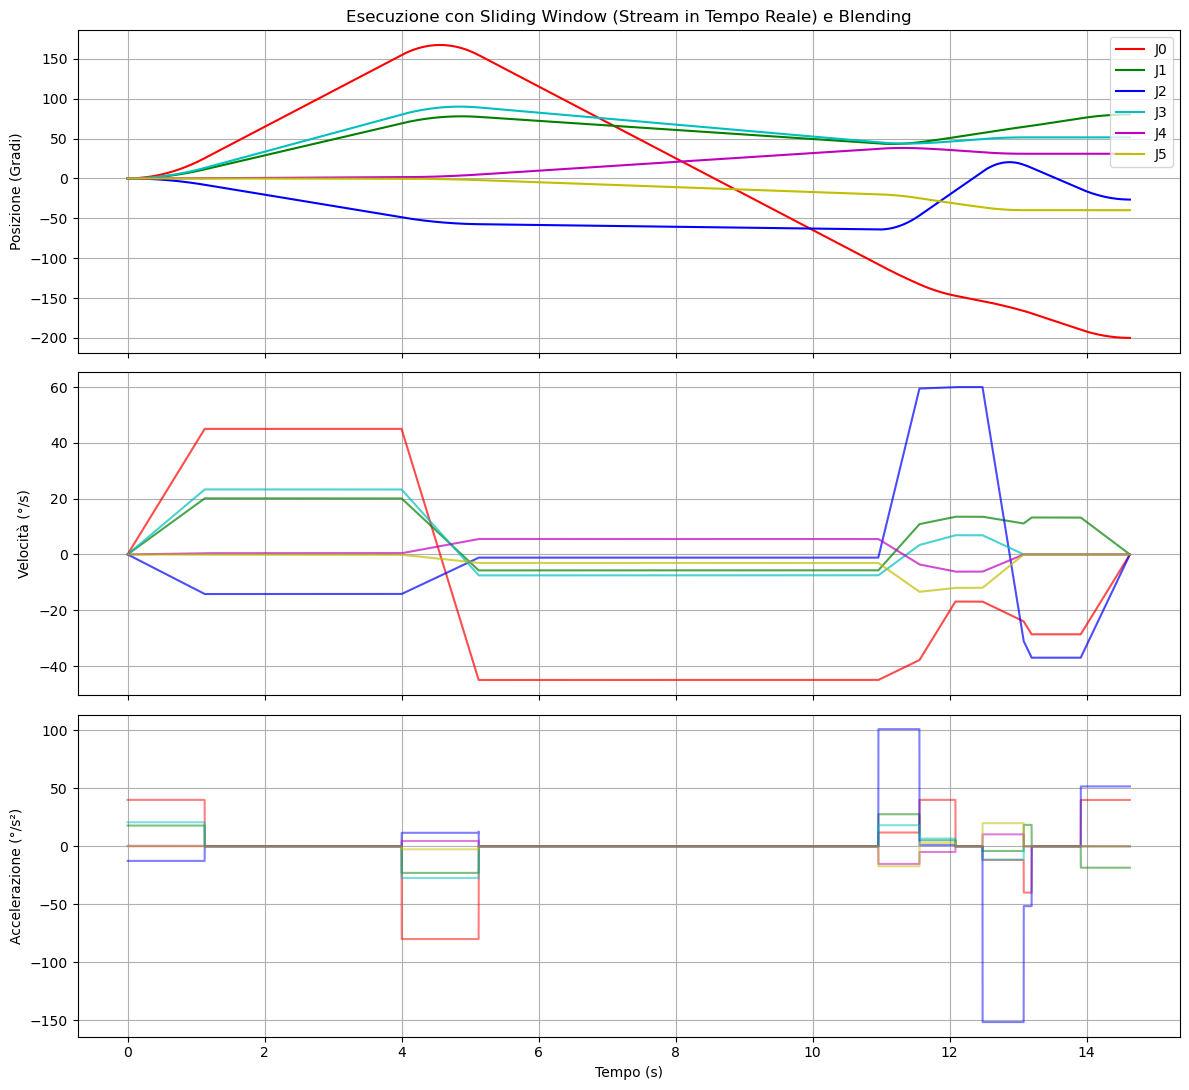

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

S_SCALE = 10000000.0  # Scala intera (0 - 10.000.000)
WINDOW_SIZE = 3       # Dimensione della finestra scorrevole (buffer RAM limitato a 3 comandi)

# ==============================================================================
# 1. PARSER G-CODE (Trasformato in Stream/Generatore)
# ==============================================================================
def stream_gcode_blocks(gcode_text):
    """
    Simula la ricezione del G-code riga per riga (es. via Seriale).
    Restituisce un blocco alla volta invece di caricare tutto in memoria.
    """
    lines = gcode_text.strip().split('\n')
    last_q = np.zeros(6) 
    
    for line in lines:
        line = line.strip()
        if not line: continue
        parts = line.split()
        cmd = parts[0]
        
        if cmd == 'G1':
            q_target = np.copy(last_q)
            for p in parts[1:]:
                val = float(p[1:])
                if p.startswith('X'): q_target[0] = val
                elif p.startswith('Y'): q_target[1] = val
                elif p.startswith('Z'): q_target[2] = val
                elif p.startswith('A'): q_target[3] = val
                elif p.startswith('B'): q_target[4] = val
                elif p.startswith('C'): q_target[5] = val
            
            block = {
                'type': 'MOTION',
                'q_target': np.copy(q_target),
                'delta_q': q_target - last_qnew_state.append(list(piolo1))
            }
            last_q = np.copy(q_target)
            
            # Sospende l'esecuzione e invia il blocco al controller
            yield block
            
        elif cmd == 'G4':
            for p in parts[1:]:
                if p.startswith('P'): 
                    yield {'type': 'DWELL', 'duration_ms': float(p[1:])}
        elif cmd == 'M280':
            yield {'type': 'TOOL', 'raw': line}

# ==============================================================================
# 2. CINEMATICA (La tua matematica esatta)
# ==============================================================================
def compute_kinematic_pure_integration(delta_q, v_max_arrnew_state.append(list(piolo1)), a_max_arr, dt=0.001):
    mask = np.abs(delta_q) > 1e-6
    if not np.any(mask):
        return {'ticks_a': 0, 'ticks_v': 0, 'a_tick': 0.0, 'ticks_tot': 0}
        
    v_norm = np.min(v_max_arr[mask] / np.abs(delta_q[mask]))
    a_norm = np.min(a_max_arr[mask] / np.abs(delta_q[mask]))
    
    t_a = v_norm / a_norm
    s_a = 0.5 * a_norm * (t_a ** 2)
    
    if 2 * s_a > 1.0:  # evita il profilo triangolare 
        s_a_target = 0.25 # percentuale del tempo di accelerazione e decelerazione 
        v_norm = np.sqrt(2.0 * a_norm * s_a_target)
        t_a = v_norm / a_norm
        s_v = 1.0 - (2.0 * s_a_target) 
        t_v = s_v / v_norm
    else: 
        t_v = (1.0 - 2 * s_a) / v_norm
        
    ticks_a = int(np.round(t_a / dt))
    ticks_v = int(np.round(t_v / dt))
    if ticks_a == 0: ticks_a = 1 
    
    a_tick = S_SCALE / (ticks_a * (ticks_a + 1 + ticks_v))
    
    return {
        'ticks_a': ticks_a,
        'ticks_v': ticks_v,
        'a_tick': a_tick,
        'ticks_tot': (2 * ticks_a) + ticks_v
    }

# ==============================================================================
# 3. CLASSE PROFILO ATTIVO (La tua logica esatta)
# ==============================================================================
class ActiveProfilePureIntegration:
    def __init__(self, block):
        self.block = block
        self.kin = block['kinematics']
        self.tick_counter = 0
        
        self.s = 0.0new_state.append(list(piolo1))
        self.v = 0.0
        
        self.is_finished = False
        self.blend_triggered = False

    def tick(self):
        if self.tick_counter >= self.kin['ticks_tot']:
            self.s = S_SCALE
            self.v = 0.0
            self.is_finished = True
            return
            
        if self.tick_counter < self.kin['ticks_a']:
            a = self.kin['a_tick']
        elif self.tick_counter < (self.kin['ticks_a'] + self.kin['ticks_v']):
            a = 0.0
        else:
            a = -self.kin['a_tick']
            
        self.v += a
        self.s += self.v
        self.tick_counter += 1

# ==============================================================================
# 4. SIMULATORE DELLA SLIDING WINDOW CORRETTO (Adattato per lo Stream)
# ==============================================================================
def simulate_sliding_window(gcode_stream, v_max_arr, a_max_arr, dt=0.001):
    time_log, q_log, v_log, a_log = [], [], [], []
    q_base = np.zeros(6)
    
    window = []
    active_profiles = []
    current_time = 0.0
    
    stream_exhausted = False  # Flag per sapere se abbiamo finito di leggere il G-code
    
    # Sotto-funzione per tenere la finestra sempre piena consumando il generatore
    def refill_window():
        nonlocal stream_exhausted
        # Aggiunge blocchi chiamando la prossima riga fino a riempire il buffer
        while len(window) < WINDOW_SIZE and not stream_exhausted:
            try:
                new_block = next(gcode_stream)
                window.append(new_block)
            except StopIteration:
                stream_exhausted = True
                break
                
        # Calcola cinematica e blending per il contenuto attuale
        for i in range(len(window)):
            b = window[i]
            if b['type'] == 'MOTION':
                if 'kinematics' not in b:
                    b['kinematics'] = compute_kinematic_pure_integration(b['delta_q'], v_max_arr, a_max_arr, dt)
                
                # Se c'è un blocco successivo ed è anch'esso di moto, abilita il blend
                if i + 1 < len(window) and window[i+1]['type'] == 'MOTION':
                    b['blend_next'] = True
                else:
                    b['blend_next'] = False

    # Ciclo Principale: continua finché c'è qualcosa da elaborare o in coda dalla "seriale"
    while active_profiles or not stream_exhausted or window:
        refill_window()
        
        # Se non ci sono movimenti in corso, prendiamo in carico il primo blocco in finestra
        if not active_profiles and window:
            b = window[0] # Controlliamo il tipo prima di estrarlo definitivamente (Peek)
            
            if b['type'] == 'DWELL':
                window.pop(0) # Ora possiamo consumarlo
                steps = int(b['duration_ms'] / 1000.0 / dt)
                for _ in range(steps):
                    time_log.append(current_time)
                    q_log.append(np.copy(q_base))
                    v_log.append(np.zeros(6))
                    a_log.append(np.zeros(6))
                    current_time += dt
                continue
            elif b['type'] == 'TOOL':
                window.pop(0) 
                continue
            elif b['type'] == 'MOTION':
                window.pop(0) 
                active_profiles.append(ActiveProfilePureIntegration(b))
        
        # Elaborazione tic-by-tic dei profili attivi
        if active_profiles:
            current_q = np.copy(q_base)
            current_v = np.zeros(6)
            current_a = np.zeros(6)
            
            latest = active_profiles[-1]
            
            # Valutazione di un innesco per il blending con il blocco successivo
            if latest.block.get('blend_next', False) and not latest.blend_triggered:
                if latest.tick_counter >= (latest.kin['ticks_a'] + latest.kin['ticks_v']):
                    latest.blend_triggered = True
                    
                    refill_window() # Assicuriamoci che la finestra sia aggiornata
                    # Estrae il prossimo blocco SOLO se è un blocco di movimento
                    if window and window[0]['type'] == 'MOTION':
                        next_b = window.pop(0)
                        active_profiles.append(ActiveProfilePureIntegration(next_b))
            
            for p in active_profiles:
                if p.tick_counter < p.kin['ticks_a']:
                    inst_a = p.kin['a_tick']
                elif p.tick_counter < (p.kin['ticks_a'] + p.kin['ticks_v']):
                    inst_a = 0.0
                elif not p.is_finished:
                    inst_a = -p.kin['a_tick']
                else:
                    inst_a = 0.0

                p.tick() 
                
                frac = p.s / S_SCALE
                current_q += frac * p.block['delta_q']
                current_v += (p.v / S_SCALE) * p.block['delta_q'] / dt
                current_a += (inst_a / S_SCALE) * p.block['delta_q'] / (dt**2)
                
            # Rimozione dei profili che hanno completato il loro percorso
            for p in active_profiles[:]:
                if p.is_finished:
                    q_base += p.block['delta_q'] 
                    active_profiles.remove(p)
                    
            time_log.append(current_time)
            q_log.append(current_q)
            v_log.append(current_v)
            a_log.append(current_a)
            current_time += dt

    return np.array(time_log), np.array(q_log), np.array(v_log), np.array(a_log)

# ==============================================================================
# 5. ESECUZIONE E PLOT
# ==============================================================================
gcode_input = """
G1 X180 Y80.38 Z-56.78 A93.22 B1.73 C-0.42
G1 X-133.22 Y40.58 Z-64.74 A40.97 B40.29 C-21.60
G1 X-158.92 Y61.16 Z26.55 A51.45 B30.90 C-39.83
G1 X-200 Y80.16 Z-26.55 A51.45 B30.90 C-39.83
"""

V_MAX_ARRAY = np.array([45.0, 45.0, 60.0, 90.0, 120.0, 120.0])
A_MAX_ARRAY = np.array([40.0, 60.0, 100.0, 150.0, 200.0, 200.0])
DT = 0.001

# Chiamata aggiornata: ora passiamo lo stream (generatore) invece della lista cruda
gcode_stream = stream_gcode_blocks(gcode_input)
t_log, q_log, v_log, a_log = simulate_sliding_window(gcode_stream, V_MAX_ARRAY, A_MAX_ARRAY, dt=DT)

fig, axs = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
labels = ['J0', 'J1', 'J2', 'J3', 'J4', 'J5']
colors = ['r', 'g', 'b', 'c', 'm', 'y']

for j in range(6): axs[0].plot(t_log, q_log[:, j], color=colors[j], label=labels[j])
axs[0].set_ylabel('Posizione (Gradi)')
axs[0].set_title('Esecuzione con Sliding Window (Stream in Tempo Reale) e Blending')
axs[0].grid(True); axs[0].legend(loc='upper right')

for j in range(6): axs[1].plot(t_log, v_log[:, j], color=colors[j], alpha=0.7)
axs[1].set_ylabel('Velocità (°/s)')
axs[1].grid(True)

for j in range(6): axs[2].plot(t_log, a_log[:, j], color=colors[j], alpha=0.5)
axs[2].set_ylabel('Accelerazione (°/s²)')
axs[2].set_xlabel('Tempo (s)')
axs[2].grid(True)

plt.tight_layout()
plt.show()